# 02 — Monte Carlo validation

Validate the analytical Garman–Kohlhagen price using Monte Carlo simulation under:
dS/S = (rd - rf) dt + sigma dW

## Correspondence with the paper
- Numerical pricing: Monte Carlo
- Convergence and confidence interval

## Outputs
- Analytical price vs MC estimate
- Terminal FX distribution
- Convergence plot vs number of paths

In [2]:
import sys
import os

# Add project root to Python path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root added:", project_root)

Project root added: c:\Users\rayzu\Pictures\fx-option-pricing-ml


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.bs_fx import garman_kohlhagen_price
from src.monte_carlo import mc_fx_price

S, K, T = 1.10, 1.10, 1.0
rd, rf = 0.02, 0.01
sigma = 0.03

bs = garman_kohlhagen_price(S, K, T, rd, rf, sigma, option="call")
mc, ci, ST = mc_fx_price(S, K, T, rd, rf, sigma, option="call", n_paths=250_000, seed=42)

print("BS price:", bs)
print("MC price:", mc)
print("95% CI  :", ci)

BS price: 0.01910073492507236
MC price: 0.019105851913949805
95% CI  : (0.019015592112358648, 0.01919611171554096)


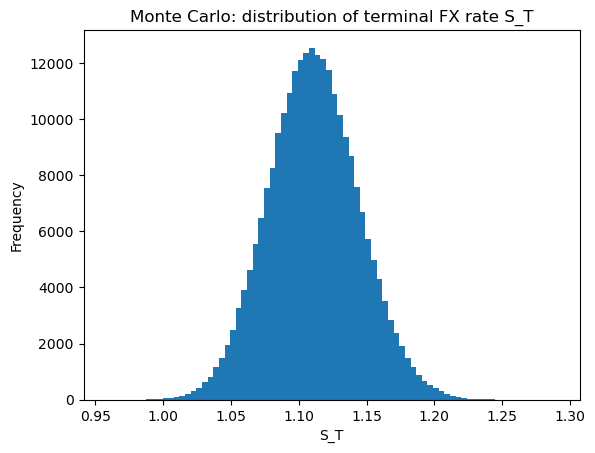

In [7]:
plt.figure()
plt.hist(ST, bins=80)
plt.xlabel("S_T")
plt.ylabel("Frequency")
plt.title("Monte Carlo: distribution of terminal FX rate S_T")
plt.savefig("../results/figures/mc_terminal_distribution.png", dpi=300)
plt.show()

In [5]:
path_grid = [2000, 5000, 10000, 20000, 50000, 100000, 200000]

ests, low, high = [], [], []
for n in path_grid:
    p, c, _ = mc_fx_price(S, K, T, rd, rf, sigma, "call", n_paths=n, seed=123)
    ests.append(p); low.append(c[0]); high.append(c[1])

df = pd.DataFrame({"n_paths": path_grid, "mc_price": ests, "ci_low": low, "ci_high": high})
df

,n_paths,mc_price,ci_low,ci_high
0,2000,0.019524,0.018511,0.020537
1,5000,0.019268,0.018633,0.019903
2,10000,0.019271,0.018824,0.019719
3,20000,0.019181,0.018862,0.019500
4,50000,0.019149,0.018947,0.019351
5,100000,0.019108,0.018966,0.019251
6,200000,0.019057,0.018957,0.019158


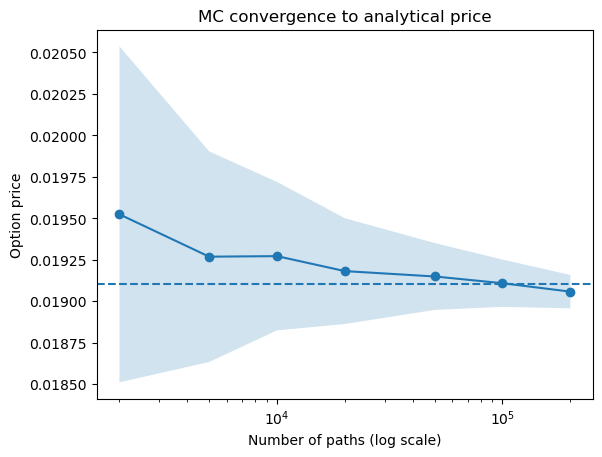

In [8]:
plt.figure()
plt.plot(df["n_paths"], df["mc_price"], marker="o")
plt.fill_between(df["n_paths"], df["ci_low"], df["ci_high"], alpha=0.2)
plt.axhline(bs, linestyle="--")
plt.xscale("log")
plt.xlabel("Number of paths (log scale)")
plt.ylabel("Option price")
plt.title("MC convergence to analytical price")
plt.savefig("../results/figures/mc_convergence.png", dpi=300)
plt.show()

# Discussion

Monte Carlo pricing converges to the analytical solution as the number of paths increases.

## Statistical insight

- Convergence rate follows O(1/sqrt(N))
- Confidence intervals shrink with sample size
- Numerical stability confirmed

## Practical implications

Monte Carlo becomes necessary when:
- No closed-form solution exists
- Path-dependent derivatives are considered

However, computational cost grows linearly with number of simulations.

This motivates surrogate ML models for speed.

## Reproducibility

All experiments were performed with:
- Random seed fixed
- Deterministic splits
- Explicit parameter ranges

This ensures full reproducibility of the results.